<a href="https://colab.research.google.com/github/thakarhiral19/PRODIGY_DS_04/blob/main/task_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd

# Load the CSV without a header and assign column names
df = pd.read_csv("twitter_training.csv", header=None, names=['tweet_id', 'entity', 'sentiment', 'tweet_text'])
print(df.head())

   tweet_id       entity sentiment  \
0      2401  Borderlands  Positive   
1      2401  Borderlands  Positive   
2      2401  Borderlands  Positive   
3      2401  Borderlands  Positive   
4      2401  Borderlands  Positive   

                                          tweet_text  
0  im getting on borderlands and i will murder yo...  
1  I am coming to the borders and I will kill you...  
2  im getting on borderlands and i will kill you ...  
3  im coming on borderlands and i will murder you...  
4  im getting on borderlands 2 and i will murder ...  


In [6]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    return text

df["Clean_Tweet"] = df["tweet_text"].apply(clean_text)

In [7]:
from textblob import TextBlob

def get_sentiment(text):
    polarity = TextBlob(text).sentiment.polarity

    if polarity > 0:
        return "Positive"
    elif polarity < 0:
        return "Negative"
    else:
        return "Neutral"

df["Predicted_Sentiment"] = df["Clean_Tweet"].apply(get_sentiment)

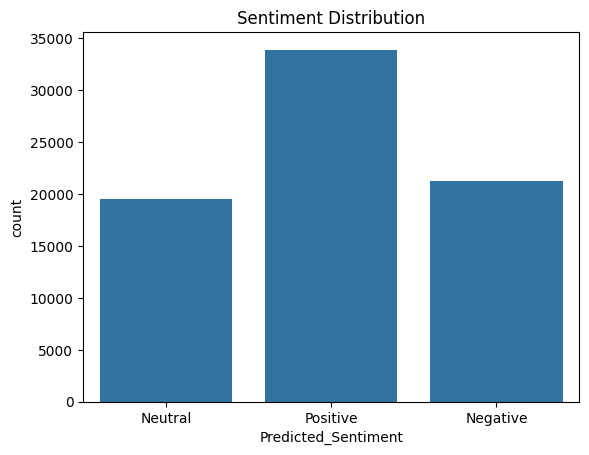

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x="Predicted_Sentiment", data=df)
plt.title("Sentiment Distribution")
plt.show()